Import necessary libraries

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import urllib.request, ssl

STEP 1: Load image from Google Drive URL

(np.float64(-0.5), np.float64(165.5), np.float64(244.5), np.float64(-0.5))

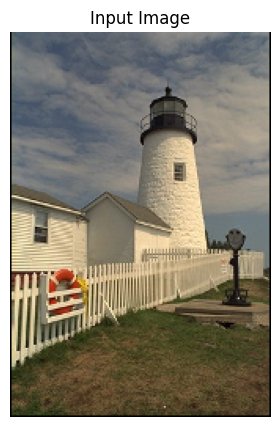

In [ ]:
url = "https://drive.google.com/uc?export=download&id=1kWIx5TR65nuAIThAUgcn31ccBsOgVQW-"
ctx = ssl._create_unverified_context()
resp = urllib.request.urlopen(url, context=ctx)
img = cv2.imdecode(np.asarray(bytearray(resp.read()), dtype=np.uint8), cv2.IMREAD_COLOR)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.figure(figsize=(5,5)); plt.imshow(img_rgb); plt.title("Input Image"); plt.axis('off')

STEP 2: Detect SIFT features and descriptors

Detected 163 SIFT keypoints.


(np.float64(-0.5), np.float64(165.5), np.float64(244.5), np.float64(-0.5))

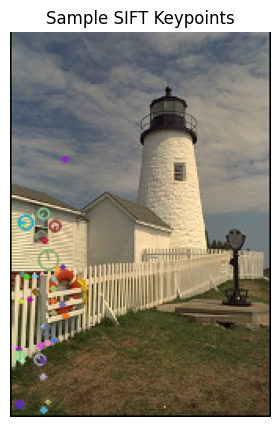

In [ ]:
# SIFT keypoints & descriptors (128-D float vectors)
sift = cv2.SIFT_create()
kps, descs = sift.detectAndCompute(gray, None)
print(f"Detected {len(kps)} SIFT keypoints.")

# Visualize some keypoints
img_kp = cv2.drawKeypoints(img, kps[:50], None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.figure(figsize=(5,5)); plt.imshow(cv2.cvtColor(img_kp, cv2.COLOR_BGR2RGB)); plt.title("Sample SIFT Keypoints"); plt.axis('off')

STEP 3: Build Visual Vocabulary using K‑means

In [ ]:
# BoVW clusters descriptors to K visual words
K = 20  # number of visual words
kmeans = KMeans(n_clusters=K, random_state=42).fit(descs)
vocabulary = kmeans.cluster_centers_
print(f"Built vocabulary with {K} visual words.")

Built vocabulary with 20 visual words.


STEP 4: BoVW Encoding

    BoVW histogram: counts of nearest visual word for each descriptor

BoVW descriptor (histogram size): (20,)


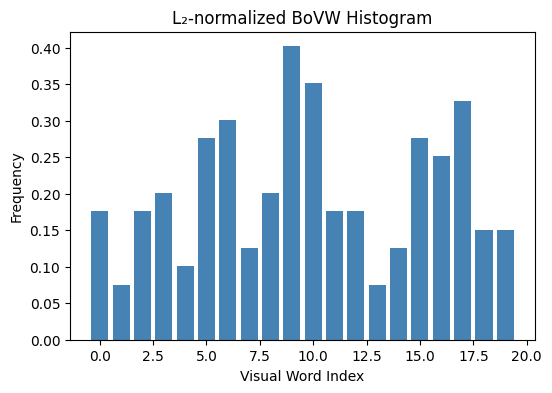

In [ ]:
words = kmeans.predict(descs)
hist_bovw, _ = np.histogram(words, bins=range(K+1))
hist_bovw = hist_bovw.astype(float) / np.linalg.norm(hist_bovw)  # L2-normalize histogram
print("BoVW descriptor (histogram size):", hist_bovw.shape)

# Visualize histogram
plt.figure(figsize=(6,4))
plt.bar(np.arange(K), hist_bovw, color='steelblue')
plt.title("L₂-normalized BoVW Histogram"); plt.xlabel("Visual Word Index"); plt.ylabel("Frequency")
plt.show()


STEP 5: VLAD Encoding

    VLAD aggregates residuals of descriptors relative to their assigned visual centers

    Formula: for each cluster k,
       v_k = sum_{i assigned to k} (x_i - c_k)
          final VLAD vector = concat([v_1, ..., v_K]), then L2-normalize

VLAD descriptor length: (2560,)


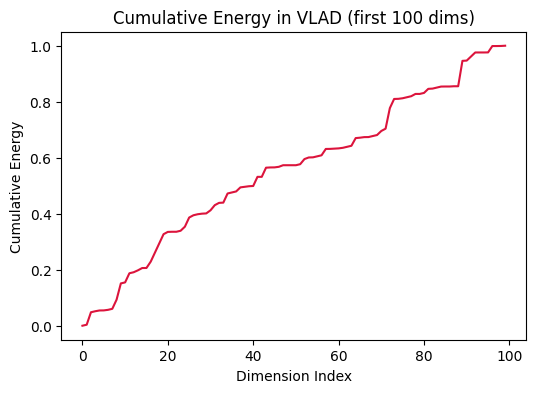

In [ ]:
descs_centered = descs - vocabulary[words]  # compute residuals
vlad = np.zeros((K, descs.shape[1]), dtype=float)
for i, w in enumerate(words):
    vlad[w] += descs_centered[i]
vlad_vector = vlad.flatten()
vlad_vector = vlad_vector / np.linalg.norm(vlad_vector)  # L2 normalize
print("VLAD descriptor length:", vlad_vector.shape)

# Plot cumulative energy of first 100 dims
plt.figure(figsize=(6,4))
plt.plot(np.cumsum(vlad_vector[:100]**2)/np.sum(vlad_vector[:100]**2), color='crimson')
plt.title("Cumulative Energy in VLAD (first 100 dims)")
plt.xlabel("Dimension Index"); plt.ylabel("Cumulative Energy")
plt.show()

STEP 6: Summary of Results

In [ ]:
print(f"\n✅ Final Global Descriptors:")
print(f"- BoVW histogram: {hist_bovw.shape}, L₂ norm = {np.linalg.norm(hist_bovw):.3f}")
print(f"- VLAD vector: {vlad_vector.shape}, L₂ norm = {np.linalg.norm(vlad_vector):.3f}")


✅ Final Global Descriptors:
- BoVW histogram: (20,), L₂ norm = 1.000
- VLAD vector: (2560,), L₂ norm = 1.000


The result you see:

```
✅ Final Global Descriptors:
- BoVW histogram: (20,), L₂ norm = 1.000
- VLAD vector: (2560,), L₂ norm = 1.000
```

means the following:

---

### 🔹 **BoVW histogram: (20,), L₂ norm = 1.000**

* **(20,)**: The BoVW (Bag of Visual Words) histogram has **20 bins** (or visual words).

  * You chose `K = 20` in the k-means clustering step, which means the local SIFT descriptors were grouped into 20 visual categories (clusters).
  * The histogram shows how many SIFT features were assigned to each visual word.
* **L₂ norm = 1.000**:

  * The histogram was normalized using **L₂ normalization**:
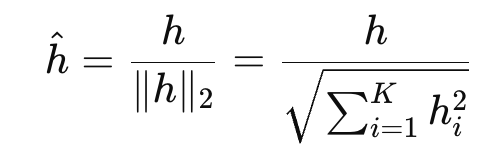
  * This is standard for BoVW so the descriptor is **scale-invariant**, allowing it to be used in comparisons or classifiers consistently.

---

### 🔹 **VLAD vector: (2560,), L₂ norm = 1.000**

* **(2560,)**: The VLAD (Vector of Locally Aggregated Descriptors) vector has **2560 dimensions**.

  * You used **K = 20** visual words (clusters) and **SIFT descriptors**, which are **128-dimensional**.
  * So the VLAD vector = $K \times 128 = 20 \times 128 = 2560$
  * Each cluster contributes a 128D vector formed by summing the **residuals** (differences from the cluster center) of the descriptors assigned to it.
* **L₂ norm = 1.000**:

  * Again, this is because you **normalized the full VLAD vector** using L₂ norm:

    $$
    \hat{v} = \frac{v}{\|v\|_2}
    $$
  * This is essential to reduce the effect of image size or number of keypoints.

---

### ✅ **Why This Is Important**

* Both descriptors are now in a **normalized vector space**.
* They are suitable for:

  * **Image classification** (using SVM or nearest neighbor)
  * **Image retrieval** (similarity search)
  * **Clustering similar scenes**
* Normalization ensures that:

  * Distance computations like cosine similarity or Euclidean distance behave properly.
  * Larger images or those with more features do not dominate the comparison.
